# Week 8: K-Nearest Neighbors (KNN) and Distance Metrics

## 1. Notebook Setup
- Import libraries

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error


plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.1)

## 2. Dataset 1: customer_churn
### 2.1 Data Overview & Preparation

In [2]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#drop null rows
customer_churn.dropna(inplace=True)
#take sample of dataset for quicker run time
sample, _ = train_test_split(
    customer_churn,
    train_size = 0.3, #use 30% of dataset
    stratify = customer_churn['Churn'],
    random_state = 42
)
#preprocessing:
target_col = "Churn"
def preprocess(df, target_col):
    X = pd.get_dummies(df.drop(target_col, axis=1), drop_first=True)
    y = df[target_col]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, y
X_cc, X_cc_scaled, y_cc = preprocess(sample, target_col)

### 2.2 KNN Classification

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_cc_scaled, y_cc, test_size=0.2, random_state=42)

param_grid = {
'n_neighbors': [3, 5, 7, 9, 11],
'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_cv.fit(X_train, y_train)
print("Best Parameters:", knn_cv.best_params_)
print("Best CV Score:", knn_cv.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9}
Best CV Score: 0.9192068971703795



Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.87      0.91     13437
         1.0       0.90      0.96      0.93     16876

    accuracy                           0.92     30313
   macro avg       0.93      0.92      0.92     30313
weighted avg       0.92      0.92      0.92     30313



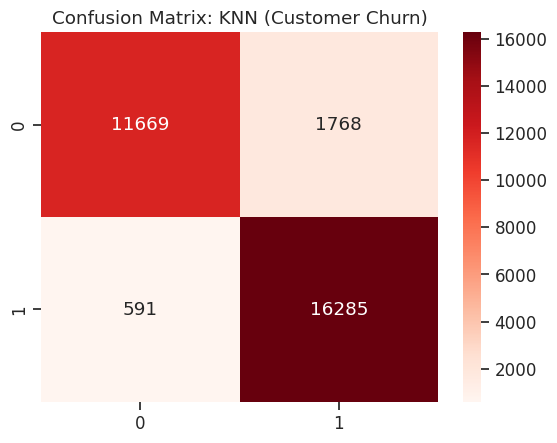

In [4]:
y_pred = knn_cv.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Reds', fmt='g')
plt.title("Confusion Matrix: KNN (Customer Churn)")
plt.show()

#### Additional plots:
[insert any plots]

## 3. Dataset 2: digital_marketing_campaign

In [5]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv")
X = pd.get_dummies(digital_marketing.drop("Conversion", axis=1, errors="ignore"), drop_first=True)
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

X_dm, X_dm_scaled, y_dm = preprocess(digital_marketing, 'Conversion')

### 3.1 KNN Classification

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dm_scaled, y_dm, test_size=0.2, random_state=42)

param_grid = {
'n_neighbors': [3, 5, 7, 9, 11],
'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_cv.fit(X_train, y_train)
print("Best Parameters:", knn_cv.best_params_)
print("Best CV Score:", knn_cv.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best CV Score: 0.8790625000000001



Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.05      0.09       194
           1       0.88      0.99      0.94      1406

    accuracy                           0.88      1600
   macro avg       0.69      0.52      0.51      1600
weighted avg       0.84      0.88      0.83      1600



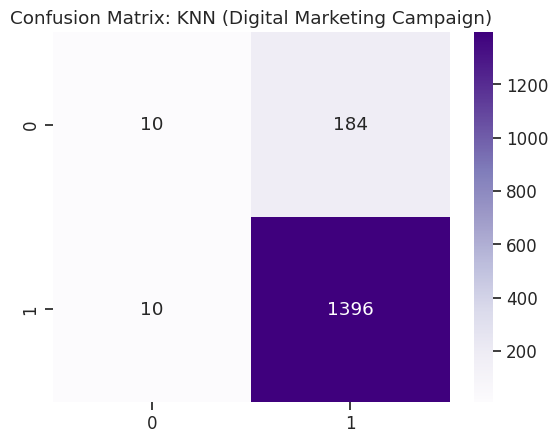

In [7]:
y_pred = knn_cv.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Purples', fmt='g')
plt.title("Confusion Matrix: KNN (Digital Marketing Campaign)")
plt.show()

## 4. Dataset 3: marketing_campaign

In [8]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=';')
#drop null rows
marketing_campaign.dropna(inplace=True)
X = pd.get_dummies(marketing_campaign.drop("Response", axis=1, errors="ignore"), drop_first=True)
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

X_mc, X_mc_scaled, y_mc = preprocess(marketing_campaign, 'Response')

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_mc_scaled, y_mc, test_size=0.2, random_state=42)

param_grid = {
'n_neighbors': [3, 5, 7, 9, 11],
'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_cv.fit(X_train, y_train)
print("Best Parameters:", knn_cv.best_params_)
print("Best CV Score:", knn_cv.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}
Best CV Score: 0.8583480544282646



Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93       382
           1       0.56      0.08      0.14        62

    accuracy                           0.86       444
   macro avg       0.71      0.54      0.53       444
weighted avg       0.83      0.86      0.82       444



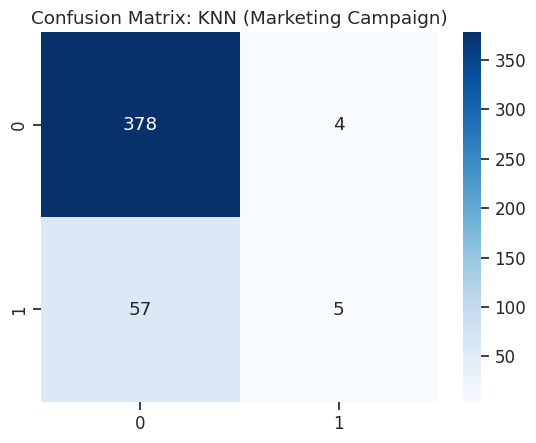

In [10]:
y_pred = knn_cv.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix: KNN (Marketing Campaign)")
plt.show()